## Handling Categorical Missing data

#### Try to replace with mode 

#### If any data have missing value are greater then 10% so make a new column of missing

In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('./train (2).csv' , usecols=['GarageQual' , 'FireplaceQu' , 'SalePrice'])

In [8]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [9]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'Number of houses')

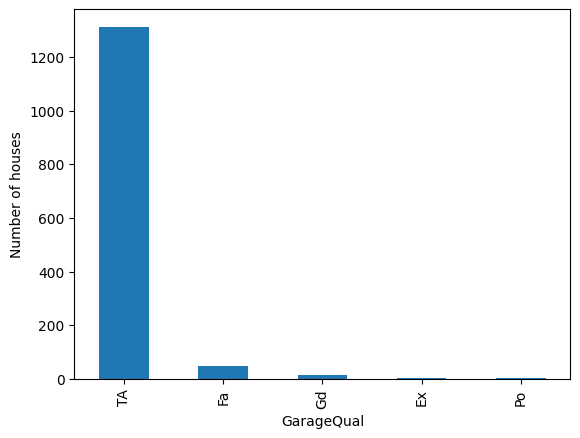

In [10]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel("GarageQual")
plt.ylabel("Number of houses")

In [11]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

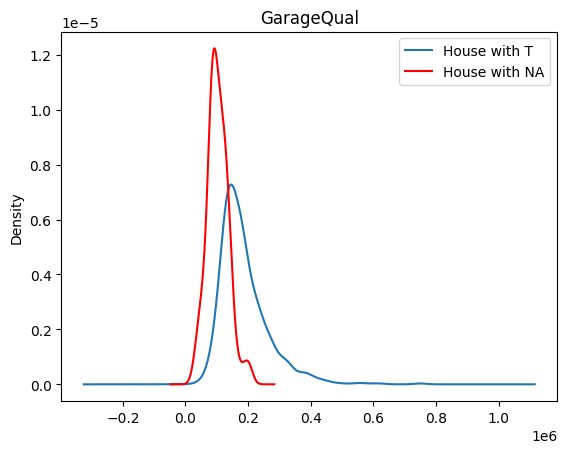

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde' , ax=ax , color='red')

lines,labels = ax.get_legend_handles_labels()
labels = ['House with T' , 'House with NA']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')

In [13]:
temp = df[df['GarageQual'] == "TA"]['SalePrice']

In [14]:
df['GarageQual'].fillna("TA" , inplace=True)

<Axes: xlabel='GarageQual'>

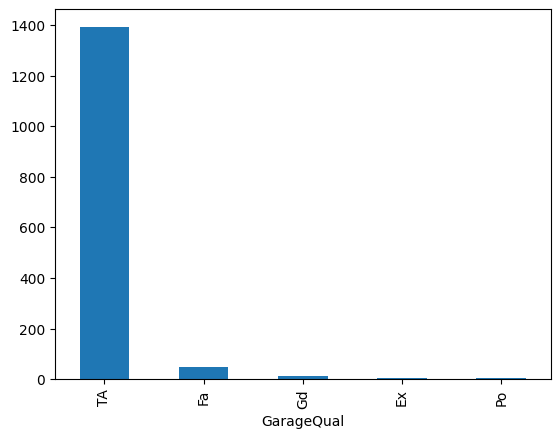

In [15]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

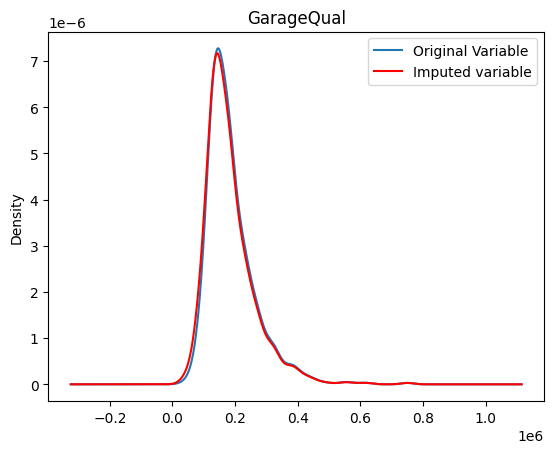

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)

# distribution of the variable after imputation
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde',ax=ax, color='red')

lines,labels = ax.get_legend_handles_labels()
labels = ['Original Variable' , 'Imputed variable']
ax.legend(lines,labels,loc='best')

# add title
plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

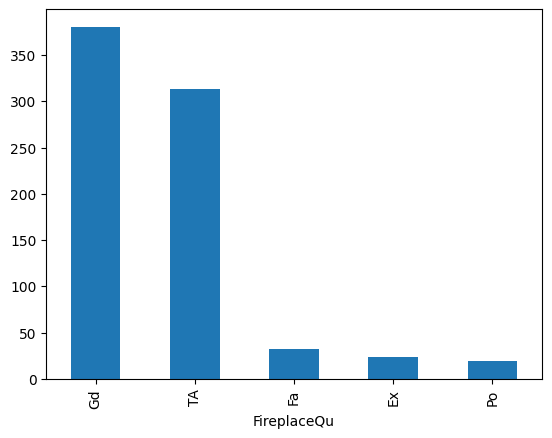

In [17]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [18]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

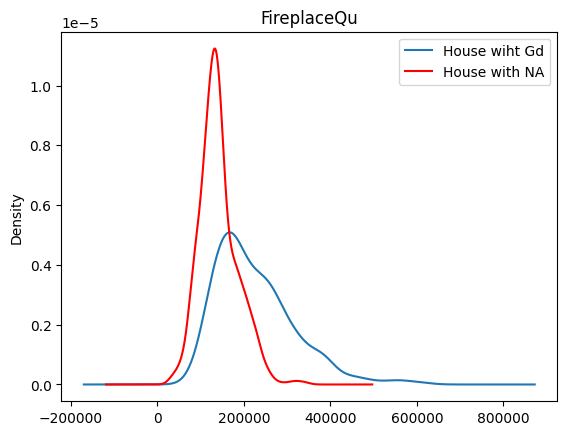

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111)

# temp.plot(kind='kde',ax=ax)

# distribution of the variable after imputation
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde',ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax, color='red')

lines,labels = ax.get_legend_handles_labels()
labels = ['House wiht Gd' , 'House with NA']
ax.legend(lines,labels,loc='best')

# add title
plt.title('FireplaceQu')

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(df.drop(columns=['SalePrice']), df['SalePrice'] , test_size=0.2)

In [21]:
from sklearn.impute import SimpleImputer

In [22]:
imputer = SimpleImputer(strategy='most_frequent')

In [23]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.fit_transform(X_test)

In [24]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)